# **LAB ASSIGNMENT - 10**

**Install Libraries**

In [17]:
!pip install transformers torchvision matplotlib

**Import Libraries**

In [15]:
import torch
import torchvision
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from transformers import ViTForImageClassification
import matplotlib.pyplot as plt
import numpy as np

**Preprocessing**

In [19]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("Transform ready")

Transform ready


**Load Dataset**

In [20]:
train_ds = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        transform=transform, download=True)

test_ds = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       transform=transform, download=True)

train_ds = Subset(train_ds, range(5000))   # from 50k → 5k
test_ds = Subset(test_ds, range(1000))     # from 10k → 1k

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)

**Load Model**

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=10,
    ignore_mismatched_sizes=True
)

model.to(device)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

**Training**

In [28]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

train_losses = []
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images).logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.0698
Epoch 2, Loss: 0.0250
Epoch 3, Loss: 0.0232


**Accuracy**

In [29]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images).logits
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 95.30%


**Predictions**

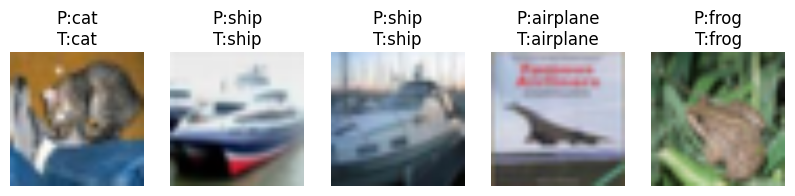

In [30]:
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

def imshow(img):
    img = img.cpu().numpy()
    plt.imshow(np.transpose(img, (1,2,0)))
    plt.axis('off')

dataiter = iter(test_loader)
images, labels = next(dataiter)

images, labels = images.to(device), labels.to(device)

outputs = model(images).logits
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    imshow(images[i])
    plt.title(f"P:{classes[predicted[i]]}\nT:{classes[labels[i]]}")

plt.show()

**Loss Graph**

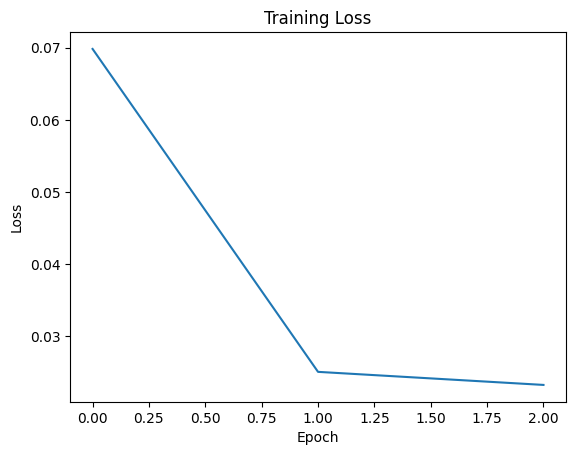

In [31]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

**Summary:** In this assignment, we worked with a Vision Transformer (ViT) model to classify images from a dataset like CIFAR-10. Instead of building a model from scratch, we used a pre-trained ViT and fine-tuned it for our task. We first prepared the data by resizing and loading it properly, then trained the model so it could learn patterns in the images. After training, we tested how well it performed using accuracy and also visualized some predictions to see if it was identifying images correctly. Overall, this helped us understand how transformer-based models can be applied to image classification and how they differ from traditional CNN approaches.